# Notebook 01 — Packet Counter Reconstruction
**Thesis §5.1–§5.2 · §7.1** | **Input:** `data/0_cleaned_dataset_Obiri_2025_2.csv` | **Output:** `data/1_reconstructed.csv`

---

## What this notebook does

LoRaWAN only records packets that *arrive* at the gateway. Packets lost in transit leave no trace in the raw data — they must be inferred from gaps in the hardware frame counter (`f_count`).

This notebook reconstructs the full loss history using two counters embedded in every uplink:

| Counter | Layer | Increments when |
|---------|-------|----------------|
| `f_count` | MAC (radio) | Radio fires a transmission |
| `p_count` | Application | App prepares a packet |

A gap of `Δf = 3` means 3 transmissions fired but only 1 arrived — so `mac_to_radio_loss = 2`.  
A gap between `p_count` and `f_count` reveals packets dropped *before* the radio fired (`app_to_mac_drop`).

**Output columns used in downstream analysis:**

| Column | Meaning |
|--------|---------|
| `mac_to_radio_loss` | Packets that entered the air but never arrived — **primary metric** |
| `app_to_mac_drop` | Packets the app prepared but the radio never transmitted |
| `is_outage` | Infrastructure downtime flag — excluded from event analysis |
| `loss_zone` | Interval classification: `no_loss`, `radio_loss`, `outage` |


## 0 · Imports & Paths

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'


In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()


print(f'Ready. Figures → {FIG_DIR.resolve()}')


Ready. Figures → D:\Thesis\lorawan_master_thesis\figures


## 1 · Load & Sort

Timestamps parsed as UTC to avoid DST ambiguity.  
Sorted per device by time — export order from InfluxDB is not guaranteed.


In [3]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} → {df["time"].max().date()}')
print(f'SF range: SF{int(df["SF"].min())}–SF{int(df["SF"].max())}')


Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-10-01 → 2025-09-30
SF range: SF7–SF12


## 2 · Packet Counter Reconstruction  *(Definition 1, §5.1)*

For each consecutive pair of received packets from the same device:

$$\ell_i = \max(\Delta f_i - 1,\ 0)$$

- `Δf` = gap in `f_count` → transmissions fired since last reception  
- `mac_to_radio_loss` = `Δf − 1` → transmissions that never arrived  
- `app_to_mac_drop` = `Δp − Δf` → packets dropped before the radio fired  

**Reset detection:** a negative `Δf` means the device rebooted and the counter reset.  
Loss count at reboot is unknowable — set to zero (conservative).


In [4]:
def reconstruct(grp):
    grp = grp.copy().reset_index(drop=True)
    delta_f = grp['f_count'].diff()
    delta_p = grp['p_count'].diff()
    is_reset = delta_f < 0

    mac_loss = (delta_f - 1).clip(lower=0)
    mac_loss[is_reset] = 0
    mac_loss.iloc[0] = 0

    app_drop = (delta_p - delta_f).clip(lower=0)
    app_drop[is_reset] = 0
    app_drop.iloc[0] = 0

    grp['mac_to_radio_loss'] = mac_loss.astype(int)
    grp['app_to_mac_drop'] = app_drop.astype(int)
    grp['total_tx'] = 1 + grp['app_to_mac_drop']
    # grp['total_tx'] = 1 + grp['mac_to_radio_loss']
    grp['is_reset'] = is_reset.fillna(False)
    return grp


device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction complete.')
print(df['device_id'].value_counts().sort_index().to_string())


Reconstruction complete.
device_id
ED0    440166
ED1    434548
ED2    440920
ED3    433579
ED4    435416
ED5    450301


## 3 · App-to-MAC Drop Analysis  *(§5.2.1)*

`p_count` grows faster than `f_count` because it increments before the radio fires.  
The cumulative difference between their ranges equals the total **app-to-MAC drops** — packets  
the application prepared but the MAC layer never transmitted.

This is an independent cross-check of the reconstruction: two different counters,  
two different arithmetic paths — if consistent, the reconstruction is validated.


In [5]:
div = df.groupby('device_id').agg(
    p_range=('p_count', lambda x: x.max() - x.min()),
    f_range=('f_count', lambda x: x.max() - x.min()),
).reset_index()
div['divergence'] = div['p_range'] - div['f_range']
div['pct'] = (div['divergence'] / div['p_range'] * 100).round(1)

print(f"{'Device':<8} {'p_range':>10} {'f_range':>10} {'divergence':>12} {'pct':>6}")
print('-' * 52)
for _, row in div.iterrows():
    print(f"{row['device_id']:<8} {int(row['p_range']):>10,} "
          f"{int(row['f_range']):>10,} {int(row['divergence']):>12,} {row['pct']:>5.1f}%")
mean_pct = div['pct'].mean()
print(f"\nMean divergence: {mean_pct:.1f}%")


Device      p_range    f_range   divergence    pct
----------------------------------------------------
ED0         203,893    183,833       20,060   9.8%
ED1         363,580    322,405       41,175  11.3%
ED2         363,603    325,311       38,292  10.5%
ED3         251,676    223,787       27,889  11.1%
ED4         363,569    322,427       41,142  11.3%
ED5         363,710    331,373       32,337   8.9%

Mean divergence: 10.5%


  Saved: figures/01_a_counter_divergence


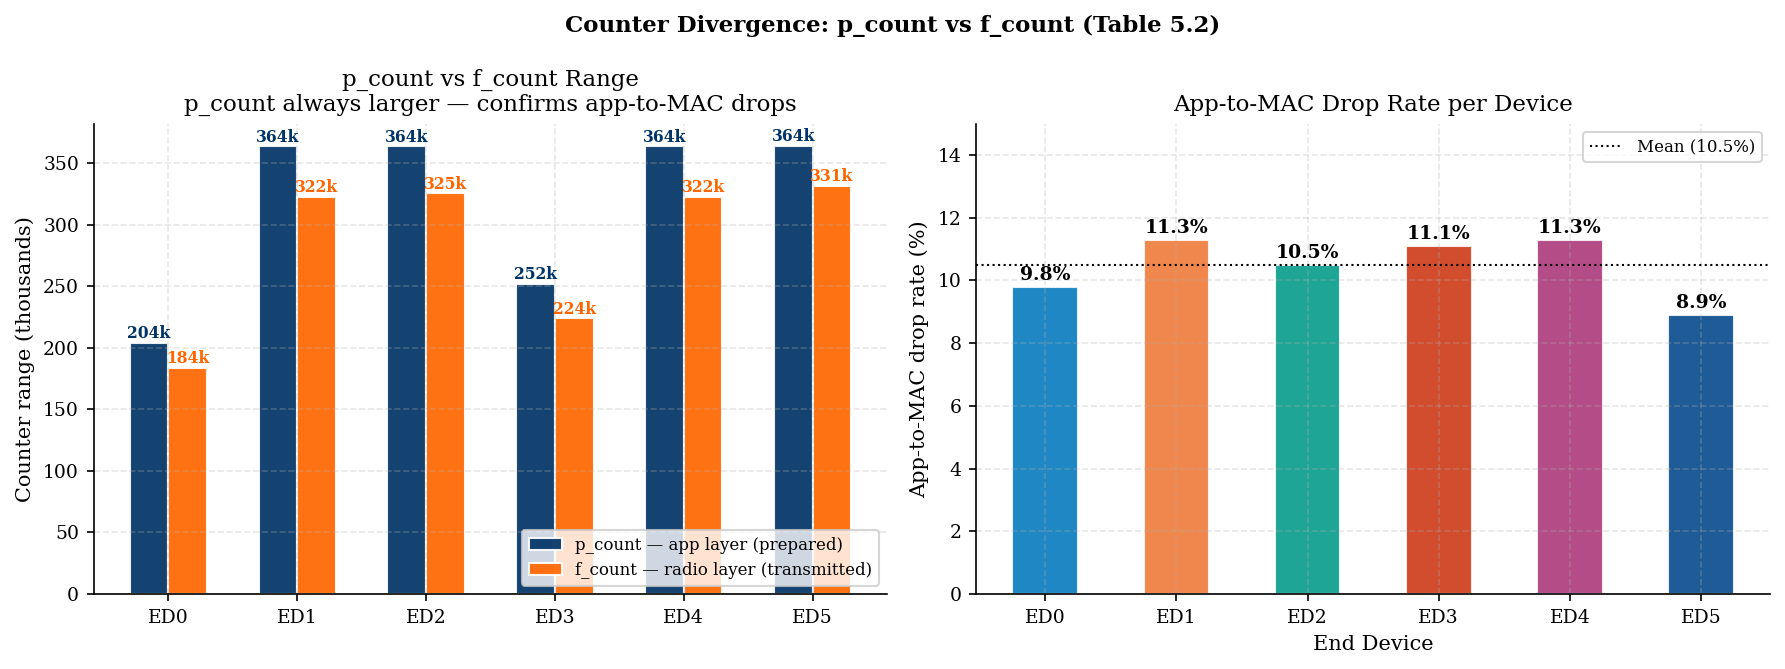

In [6]:
# Fig 01_a — p_count vs f_count divergence per device
div_data = div.copy()
DEVICES_D = div_data['device_id'].tolist()
x = np.arange(len(DEVICES_D));
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

b1 = axes[0].bar(x - w / 2, div_data['p_range'] / 1000, w, color='#003366',
                 alpha=0.92, edgecolor='white', label='p_count — app layer (prepared)')
b2 = axes[0].bar(x + w / 2, div_data['f_range'] / 1000, w, color='#FF6600',
                 alpha=0.92, edgecolor='white', label='f_count — radio layer (transmitted)')
for bar, v in zip(b1, div_data['p_range'] / 1000):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#003366', fontweight='bold')
for bar, v in zip(b2, div_data['f_range'] / 1000):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#FF6600', fontweight='bold')
axes[0].set_xticks(x);
axes[0].set_xticklabels(DEVICES_D)
axes[0].set_ylabel('Counter range (thousands)')
axes[0].set_title('p_count vs f_count Range\np_count always larger — confirms app-to-MAC drops')
axes[0].legend(fontsize=8, loc='lower right')

bars = axes[1].bar(DEVICES_D, div_data['pct'],
                   color=DEVICE_COLORS[:len(DEVICES_D)], width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, div_data['pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=mean_pct, color='black', lw=1.0, ls=':', label=f'Mean ({mean_pct:.1f}%)')
axes[1].set_ylabel('App-to-MAC drop rate (%)')
axes[1].set_xlabel('End Device')
axes[1].set_title('App-to-MAC Drop Rate per Device')
axes[1].set_ylim(0, 15)
axes[1].legend(fontsize=8, loc='upper right')

fig.suptitle('Counter Divergence: p_count vs f_count (Table 5.2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_a_counter_divergence')


### Root Cause — LoRaWAN Duty Cycle Enforcement  *(§5.2.1)*

After each transmission the device must remain silent for **99 × ToA** milliseconds  
(ETSI EN 300 220, 1% duty cycle). For SF11 and SF12 this silence exceeds the 60s TX interval:

| SF | ToA (ms) | Required silence (s) | Exceeds 60s? | Observed block size |
|----|----------|---------------------|--------------|---------------------|
| SF7 | 71.9 | 7.1 | No | 5 |
| SF8 | 133.6 | 13.2 | No | 5 |
| SF9 | 246.8 | 24.4 | No | 5 |
| SF10 | 452.6 | 44.8 | No | 5 |
| SF11 | 987.1 | 97.7 | **YES** | **4** |
| SF12 | 1810.4 | 179.2 | **YES** | **4** |

The firmware attempts 5 transmissions per SF block but the MAC enforces the cooldown,  
truncating SF11 and SF12 blocks to 4 packets. This drops 2 packets per 30-attempt cycle:

**Theoretical drop rate: 2/30 = 6.67%** | **Observed mean: ~10.5%**  
The remaining ~3.8% comes from occasional further truncation to 3-packet blocks  
and session interruptions (resets, outages) affecting all SFs.


In [7]:
from itertools import groupby
from statistics import median
from collections import Counter

actual_blocks = {}
for sf in [7, 8, 9, 10, 11, 12]:
    sizes = [sum(1 for _ in v)
             for k, v in groupby(df[df['device_id'] == 'ED0']['SF'].values)
             if k == sf]
    actual_blocks[sf] = int(median(sizes))

print('=== Duty Cycle Constraint vs Observed Block Size ===')
print('Rule: silence = 99 × ToA  (ETSI EN 300 220 | LoRaWAN Regional Parameters v1.0.3)\n')
print(f'{"SF":<5} {"ToA(ms)":>10} {"Silence(s)":>12} {"Silence > 60s?":>15} {"Median block":>13}')
print('-' * 58)
for sf in [7, 8, 9, 10, 11, 12]:
    toa = TOA_MS[sf]
    silence = 99 * toa / 1000
    exceeds = 'YES — truncated' if silence > 60 else 'No'
    print(f'SF{sf:<3} {toa:>10.1f} {silence:>12.1f} {exceeds:>15} {actual_blocks[sf]:>13}')

dropped = sum(5 - actual_blocks[sf] for sf in [7, 8, 9, 10, 11, 12])
theory = dropped / 30 * 100
print(f'\nDropped per cycle   : {int(dropped)}/30 = {theory:.2f}%')
print(f'Observed mean       : {mean_pct:.1f}%')
print(f'Duty cycle explains : {theory / mean_pct * 100:.0f}% of observed divergence')

print('\n=== Block Size Variance (ED0) ===')
for sf in [7, 8, 9, 10, 11, 12]:
    sizes = [sum(1 for _ in v)
             for k, v in groupby(df[df['device_id'] == 'ED0']['SF'].values)
             if k == sf]
    c = Counter(sizes)
    pct5 = c.get(5, 0) / sum(c.values()) * 100
    print(f'SF{sf}: {dict(sorted(c.items()))}  — full blocks: {pct5:.1f}%')

print(f'\nConclusion:')
print(f'  1. Duty cycle enforcement (SF11/SF12)  — systematic  ({theory:.1f}%)')
print(f'  2. Session interruptions (all SFs)     — random      ({mean_pct - theory:.1f}%)')


=== Duty Cycle Constraint vs Observed Block Size ===
Rule: silence = 99 × ToA  (ETSI EN 300 220 | LoRaWAN Regional Parameters v1.0.3)

SF       ToA(ms)   Silence(s)  Silence > 60s?  Median block
----------------------------------------------------------
SF7         71.9          7.1              No             5
SF8        133.6         13.2              No             5
SF9        246.8         24.4              No             5
SF10       452.6         44.8              No             5
SF11       987.1         97.7 YES — truncated             4
SF12      1810.4        179.2 YES — truncated             4

Dropped per cycle   : 2/30 = 6.67%
Observed mean       : 10.5%
Duty cycle explains : 64% of observed divergence

=== Block Size Variance (ED0) ===
SF7: {1: 91, 2: 46, 3: 113, 4: 667, 5: 17280, 6: 1}  — full blocks: 95.0%
SF8: {1: 96, 2: 90, 3: 217, 4: 637, 5: 17155, 6: 1}  — full blocks: 94.3%
SF9: {1: 156, 2: 419, 3: 247, 4: 969, 5: 16244, 6: 1, 7: 1}  — full blocks: 90.1%
SF10: {1

## 4 · Loss Distribution & Outage Detection  *(§5.2)*

The `mac_to_radio_loss` distribution reveals two natural zones:

| Zone | Loss range | Share | Interpretation |
|------|-----------|-------|----------------|
| Radio loss | 1–10 | 98.9% | Dense cluster — genuine radio-layer failures |
| Outage | > 10 | 1.1% | Sparse tail — infrastructure failure |

**Boundary at loss = 10:** values 1–10 form a dense cluster (35,154 down to 57 per value).  
Loss = 11 drops sharply to 32 — the natural break point, derived from the data, not assumed.

**Outage identification:** All intervals with `mac_to_radio_loss > 10` are flagged.  
Events affecting all 6 devices on the same date confirm logging server downtime  
(Obiri, personal communication, 2025) — not individual radio failures.


In [8]:
losses = df[df['mac_to_radio_loss'] > 0]['mac_to_radio_loss']
RADIO_MAX = 10

print(f'{"Loss":<8} {"Count":>8} {"% of losses":>13}')
print('-' * 32)
for v in range(1, 25):
    cnt = int((losses == v).sum())
    if cnt > 0:
        print(f'{v:<8} {cnt:>8,} {cnt / len(losses) * 100:>12.2f}%')
print('-' * 32)
print(f'{"Total":<8} {len(losses):>8,} {"100.00%":>13}')

print(f'\n=== Zone Summary ===')
radio = int(losses.between(1, RADIO_MAX).sum())
outage = int((losses > RADIO_MAX).sum())
print(f'Radio  (1–{RADIO_MAX})  : {radio:>8,}  ({radio / len(losses) * 100:.1f}%)')
print(f'Outage (>{RADIO_MAX})   : {outage:>8,}  ({outage / len(losses) * 100:.1f}%)')

print(f'\n{"Device":<8} {"Radio (1-10)":>13} {"Outage (>10)":>13}')
print('-' * 36)
for dev, g in df.groupby('device_id'):
    dl = g[g['mac_to_radio_loss'] > 0]['mac_to_radio_loss']
    print(f'{dev:<8} {int(dl.between(1, RADIO_MAX).sum()):>13,} '
          f'{int((dl > RADIO_MAX).sum()):>13,}')


Loss        Count   % of losses
--------------------------------
1          35,154        80.39%
2           5,570        12.74%
3           1,120         2.56%
4             545         1.25%
5             455         1.04%
6             144         0.33%
7              75         0.17%
8              65         0.15%
9              46         0.11%
10             57         0.13%
11             32         0.07%
12             28         0.06%
13             21         0.05%
14             12         0.03%
15             20         0.05%
16             11         0.03%
17              8         0.02%
18              4         0.01%
19             10         0.02%
20              6         0.01%
21              4         0.01%
22              3         0.01%
23              9         0.02%
24              7         0.02%
--------------------------------
Total      43,730       100.00%

=== Zone Summary ===
Radio  (1–10)  :   43,231  (98.9%)
Outage (>10)   :      499  (1.1%)

Device    

In [9]:
# Flag outages — all intervals with mac_to_radio_loss > RADIO_MAX
df['is_outage'] = df['mac_to_radio_loss'] > RADIO_MAX

# Outage event table — one row per date, shows cross-device simultaneity
large = df[df['is_outage']][['device_id', 'time', 'mac_to_radio_loss']].copy()
large['date'] = large['time'].dt.date
large['hrs'] = (large['mac_to_radio_loss'] * 60 / 3600).round(1)
dates_map = {d: i + 1 for i, d in enumerate(sorted(large['date'].unique()))}
large['event'] = large['date'].map(dates_map)

summary = large.groupby('event').agg(
    date=('date', 'first'),
    n_devices=('device_id', 'nunique'),
    device_ids=('device_id', lambda x: ','.join(sorted(x.unique()))),
    max_hrs=('hrs', 'max')
).reset_index()

print(f'Outage intervals: {len(large):,}  |  Unique events: {large["event"].nunique()}')
print(f"\n{'Event':^6} {'Date':^12} {'N':^4} {'Devices Affected':^30} {'Max Dur (hrs)':^14}")
print('-' * 70)
for _, row in summary.iterrows():
    print(f"{int(row['event']):^6} {str(row['date']):^12} "
          f"{int(row['n_devices']):^4} {row['device_ids']:^30} "
          f"{row['max_hrs']:^14.1f}")

print(f'\nis_outage: {df["is_outage"].sum():,} intervals flagged')


Outage intervals: 499  |  Unique events: 73

Event      Date      N          Devices Affected        Max Dur (hrs) 
----------------------------------------------------------------------
  1     2024-10-02   1                ED0                    0.2      
  2     2024-10-09   6      ED0,ED1,ED2,ED3,ED4,ED5          0.5      
  3     2024-10-10   6      ED0,ED1,ED2,ED3,ED4,ED5          4.5      
  4     2024-10-11   6      ED0,ED1,ED2,ED3,ED4,ED5          1.1      
  5     2024-10-13   6      ED0,ED1,ED2,ED3,ED4,ED5          15.0     
  6     2024-10-14   6      ED0,ED1,ED2,ED3,ED4,ED5          0.9      
  7     2024-10-15   6      ED0,ED1,ED2,ED3,ED4,ED5          0.4      
  8     2024-10-16   6      ED0,ED1,ED2,ED3,ED4,ED5          0.8      
  9     2024-10-17   6      ED0,ED1,ED2,ED3,ED4,ED5          1.5      
  10    2024-10-18   5        ED0,ED1,ED3,ED4,ED5            0.2      
  11    2024-10-21   1                ED5                    0.2      
  12    2024-10-23   6      ED0,

  Saved: figures/01_b_loss_distribution_zones


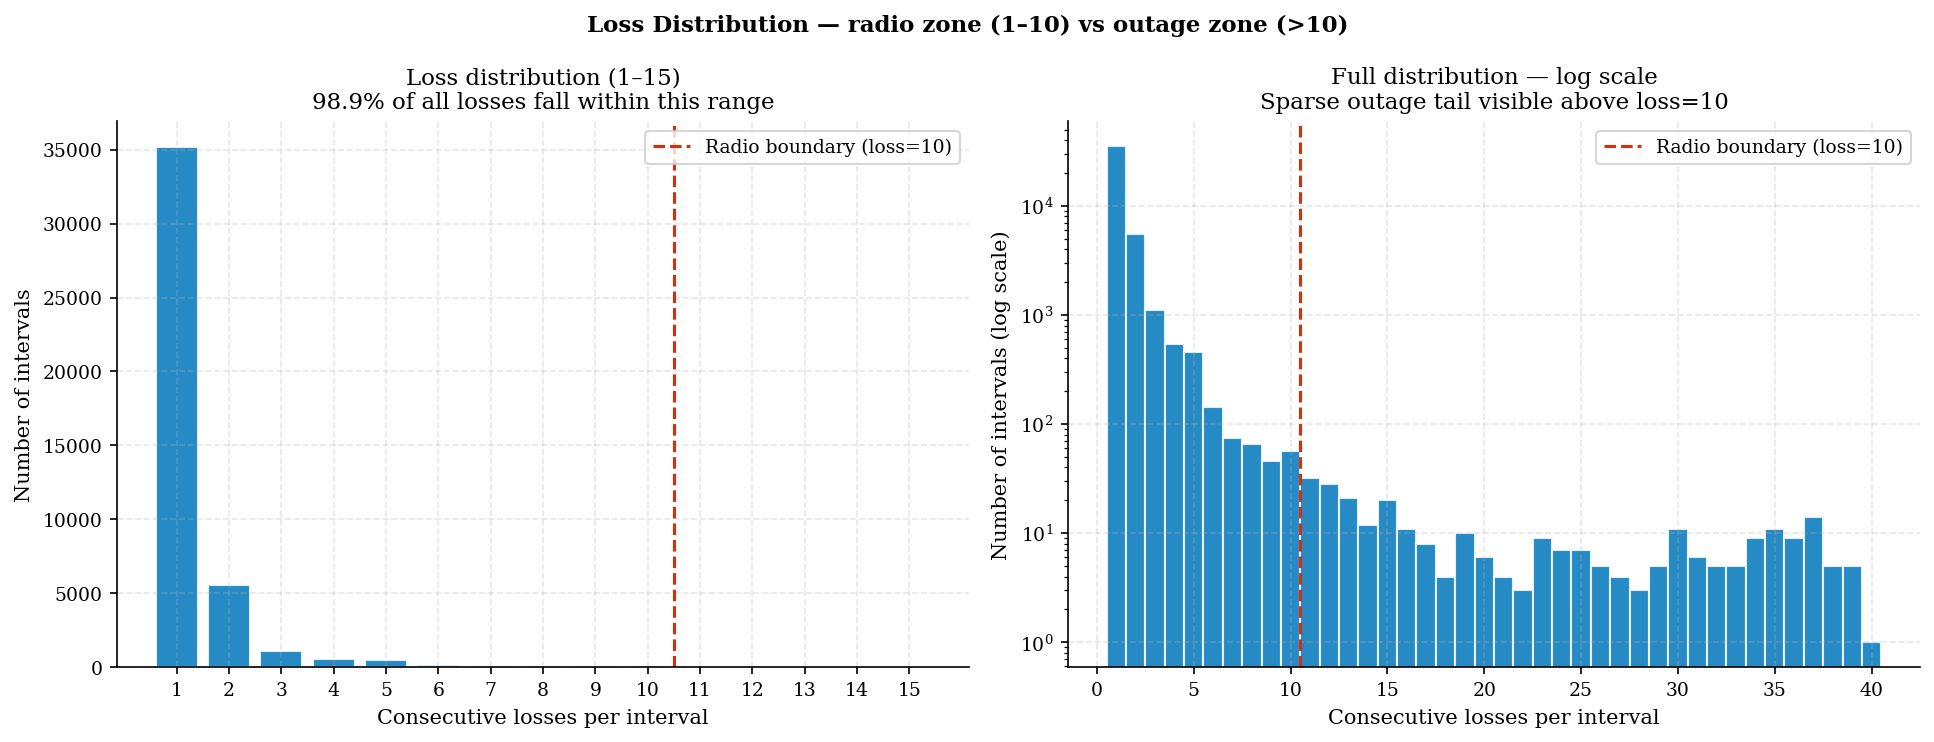

In [10]:
# Fig 01_b — Loss distribution with zone boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lz = losses[losses <= 15].value_counts().sort_index()
axes[0].bar(lz.index, lz.values, color=C['blue'], width=0.8, alpha=0.85, edgecolor='white')
axes[0].axvline(x=10.5, color=C['red'], lw=1.5, ls='--', label='Radio boundary (loss=10)')
axes[0].set_xlabel('Consecutive losses per interval')
axes[0].set_ylabel('Number of intervals')
axes[0].set_title('Loss distribution (1–15)\n98.9% of all losses fall within this range')
axes[0].set_xticks(range(1, 16))
axes[0].legend()

lc = losses[losses <= 40].value_counts().sort_index()
axes[1].bar(lc.index, lc.values, color=C['blue'], width=1, alpha=0.85, edgecolor='white')
axes[1].axvline(x=10.5, color=C['red'], lw=1.5, ls='--', label='Radio boundary (loss=10)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Consecutive losses per interval')
axes[1].set_ylabel('Number of intervals (log scale)')
axes[1].set_title('Full distribution — log scale\nSparse outage tail visible above loss=10')
axes[1].legend()

fig.suptitle('Loss Distribution — radio zone (1–10) vs outage zone (>10)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_b_loss_distribution_zones')


## 5 · Loss Zone Classification  *(§5.2)*

Each interval is assigned to one of three mutually exclusive zones.

| Zone | Condition | Interpretation |
|------|-----------|----------------|
| `no_loss` | loss = 0 | Clean reception |
| `radio_loss` | 1–10 | Genuine radio-layer failure |
| `outage` | > 10 | Infrastructure downtime — excluded from event analysis |


In [11]:
def classify_zone(row):
    if row['is_outage']:                return 'outage'
    if row['mac_to_radio_loss'] == 0:   return 'no_loss'
    return 'radio_loss'


df['loss_zone'] = df.apply(classify_zone, axis=1)

counts = df['loss_zone'].value_counts()
print(f"{'Zone':<15} {'Intervals':>12} {'Pct':>8}")
print('-' * 38)
for zone, cnt in counts.items():
    print(f'{zone:<15} {cnt:>12,} {cnt / len(df) * 100:>7.2f}%')


Zone               Intervals      Pct
--------------------------------------
no_loss            2,591,200   98.34%
radio_loss            43,231    1.64%
outage                   499    0.02%


  Saved: figures/01_c_loss_zones


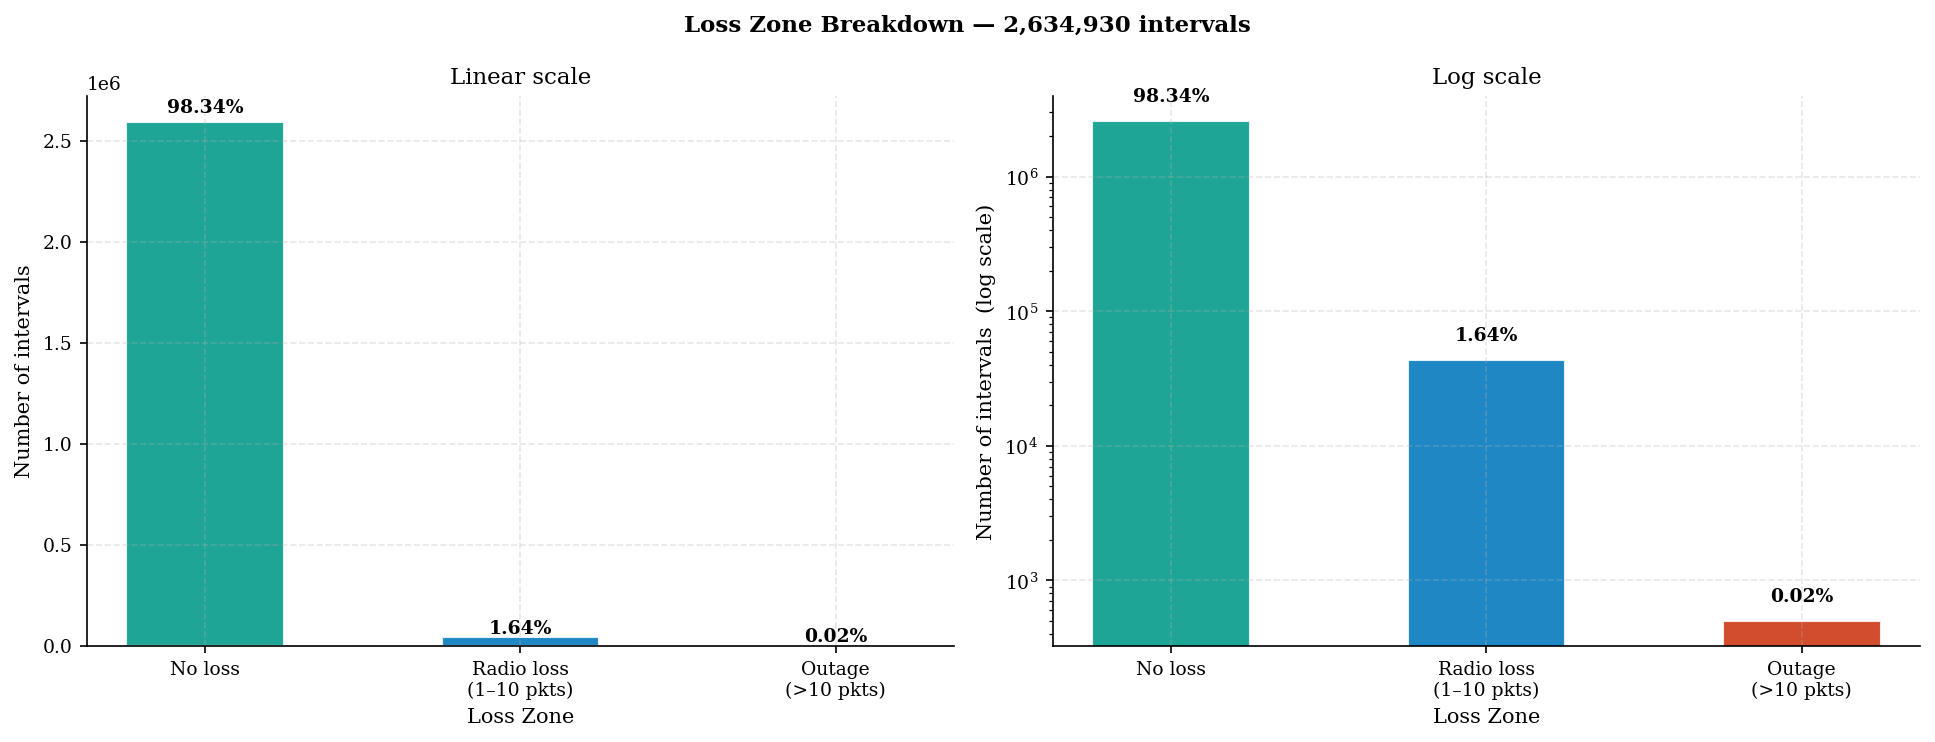

In [12]:
# Fig 01_c — Loss Zone Breakdown (linear + log)
zones = ['no_loss', 'radio_loss', 'outage']
zlabels = ['No loss', 'Radio loss\n(1–10 pkts)', 'Outage\n(>10 pkts)']
zcolors = [C['green'], C['blue'], C['red']]
zcounts = df['loss_zone'].value_counts().reindex(zones).fillna(0)
zpcts = zcounts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scale in zip(axes, ['linear', 'log']):
    bars = ax.bar(zlabels, zcounts.values, color=zcolors, width=0.5, alpha=0.88, edgecolor='white')
    if scale == 'log':
        ax.set_yscale('log')
        offset = lambda v: v * 1.3
    else:
        offset = lambda v: v * 1.01
    for bar, cnt, pct in zip(bars, zcounts.values, zpcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, offset(cnt),
                f'{pct:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'Number of intervals{"  (log scale)" if scale == "log" else ""}')
    ax.set_xlabel('Loss Zone')
    ax.set_title(f'{"Linear" if scale == "linear" else "Log"} scale')

fig.suptitle(f'Loss Zone Breakdown — {len(df):,} intervals', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_c_loss_zones')


## 6 · PDR Decomposition  *(§7.1)*

Three PDR values strip losses layer by layer to isolate true environmental reliability.

| Metric | Excludes | Interpretation |
|--------|---------|----------------|
| `PDR_system` | nothing | Application layer — every packet the app prepared |
| `PDR_raw` | app-to-MAC drops | Radio layer — every packet the radio fired |
| `PDR_link` | app-to-MAC drops + outages | Environmental reliability — used in all event analysis |

**`PDR_link` is the metric used throughout Notebook 03.**


In [13]:
total_rx = len(df)
total_app_drops = int(df['app_to_mac_drop'].sum())
total_radio_lost = int(df['mac_to_radio_loss'].sum())
df_link = df[~df['is_outage']]
total_link_lost = int(df_link['mac_to_radio_loss'].sum())

pdr_system = total_rx / (total_rx + total_app_drops + total_radio_lost) * 100
pdr_raw = total_rx / (total_rx + total_radio_lost) * 100
pdr_link = len(df_link) / (len(df_link) + total_link_lost) * 100

print(f'PDR_system : {pdr_system:.2f}%  (app + radio losses)')
print(f'PDR_raw    : {pdr_raw:.2f}%  (radio losses only)')
print(f'PDR_link   : {pdr_link:.2f}%  (radio losses, outages excluded)')
print(f'\napp-to-MAC drops account for : {pdr_raw - pdr_system:.2f} pp')
print(f'outage losses account for    : {pdr_link - pdr_raw:.2f} pp')

print(f'\nPer-device PDR_link:')
for dev, g in df_link.groupby('device_id'):
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    dist = int(df[df['device_id'] == dev]['distance'].iloc[0])
    print(f'  {dev} ({dist}m): {rx / (rx + lost) * 100:.2f}%')


PDR_system : 83.77%  (app + radio losses)
PDR_raw    : 91.04%  (radio losses only)
PDR_link   : 97.88%  (radio losses, outages excluded)

app-to-MAC drops account for : 7.28 pp
outage losses account for    : 6.84 pp

Per-device PDR_link:
  ED0 (10m): 97.92%
  ED1 (8m): 97.36%
  ED2 (23m): 98.13%
  ED3 (18m): 97.16%
  ED4 (37m): 97.68%
  ED5 (40m): 99.02%


  Saved: figures/01_d_pdr_decomposition_per_device


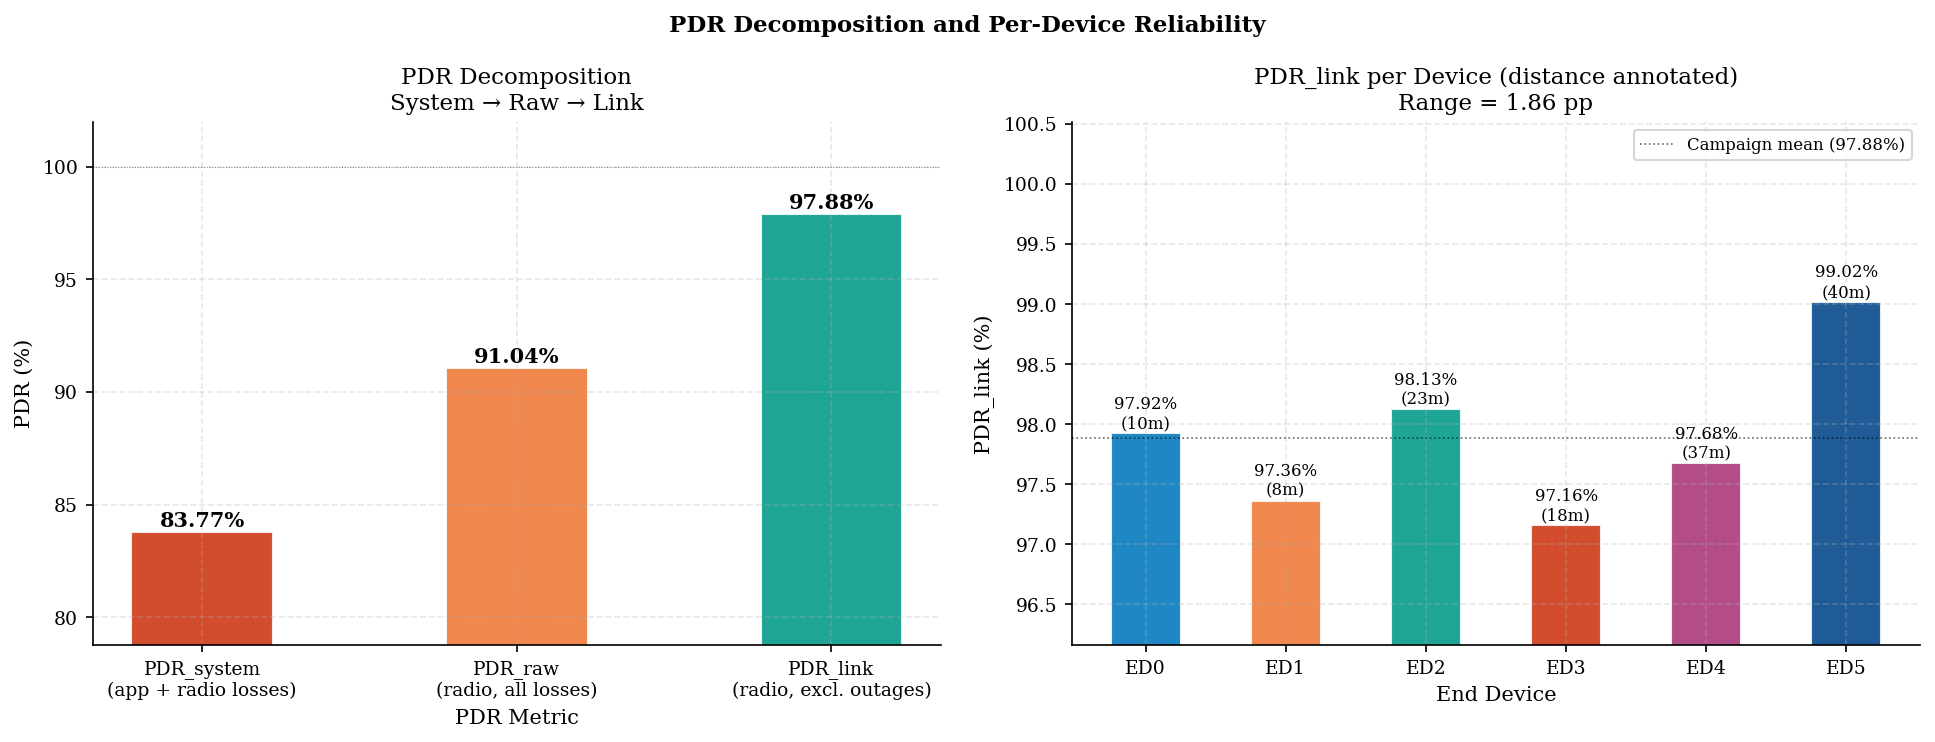

In [14]:
# Fig 01_d — PDR Decomposition + Per-Device PDR_link
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = ['PDR_system\n(app + radio losses)',
              'PDR_raw\n(radio, all losses)',
              'PDR_link\n(radio, excl. outages)']
values_v = [pdr_system, pdr_raw, pdr_link]
colors_v = [C['red'], C['orange'], C['green']]

bars = axes[0].bar(categories, values_v, color=colors_v,
                   width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(min(values_v) - 5, 102)
axes[0].set_ylabel('PDR (%)')
axes[0].set_xlabel('PDR Metric')
axes[0].axhline(y=100, color='grey', lw=0.5, ls=':')
axes[0].set_title('PDR Decomposition\nSystem → Raw → Link')

DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g = df_link[df_link['device_id'] == dev]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    dev_pdrs.append(rx / (rx + lost) * 100)
    dev_dists.append(int(df[df['device_id'] == dev]['distance'].iloc[0]))

bars2 = axes[1].bar(DEVICES_P, dev_pdrs,
                    color=DEVICE_COLORS[:len(DEVICES_P)], width=0.5, alpha=0.88, edgecolor='white')
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.2f}%\n({d}m)', ha='center', va='bottom', fontsize=8)
axes[1].axhline(y=pdr_link, color='black', lw=0.8, ls=':', alpha=0.6,
                label=f'Campaign mean ({pdr_link:.2f}%)')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_xlabel('End Device')
axes[1].set_ylim(min(dev_pdrs) - 1, max(dev_pdrs) + 1.5)
axes[1].set_title(f'PDR_link per Device (distance annotated)\n'
                  f'Range = {max(dev_pdrs) - min(dev_pdrs):.2f} pp')
axes[1].legend(fontsize=8)

fig.suptitle('PDR Decomposition and Per-Device Reliability', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_d_pdr_decomposition_per_device')


## 7 · Per-Device Loss Breakdown  *(Table 7.1, §7.1)*

Full decomposition of all loss components per device.  
`Total Lost = App-MAC + Outage losses + Link losses`

**Copy PDR_link values to Table 7.1 in the thesis.**


In [15]:
print(f"{'Dev':<6} {'Dist':^6} {'CW':^4} {'WW':^4} "
      f"{'Received':^10} {'App-MAC':^9} {'Outage':^9} {'Link Loss':^11} "
      f"{'PDR_system':^11} {'PDR_raw':^9} {'PDR_link':^10}")
print('-' * 112)

totals = {'rx': 0, 'app_mac': 0, 'outage': 0, 'link': 0}

for dev, g in df.groupby('device_id'):
    rx = len(g)
    app_mac = int(g['app_to_mac_drop'].sum())
    outage = int(g[g['is_outage']]['mac_to_radio_loss'].sum())
    g_link = g[~g['is_outage']]
    link = int(g_link['mac_to_radio_loss'].sum())
    total_lost = app_mac + outage + link
    radio_lost = outage + link  # all radio losses

    for k, v in [('rx', rx), ('app_mac', app_mac), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_sys = rx / (rx + total_lost) * 100  # app + radio losses
    pdr_raw = rx / (rx + radio_lost) * 100  # radio losses only
    pdr_lnk = len(g_link) / (len(g_link) + link) * 100  # excl. outages
    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])

    print(f"{dev:<6} {dist:^6} {cw:^4} {ww:^4} "
          f"{rx:^10,} {app_mac:^9,} {outage:^9,} {link:^11,} "
          f"{pdr_sys:^11.2f} {pdr_raw:^9.2f} {pdr_lnk:^10.2f}")

print('-' * 112)
t = totals
total = t['app_mac'] + t['outage'] + t['link']
radio_lost = t['outage'] + t['link']
print(f"{'Total':<6} {'':^6} {'':^4} {'':^4} "
      f"{t['rx']:^10,} {t['app_mac']:^9,} {t['outage']:^9,} {t['link']:^11,} "
      f"{t['rx'] / (t['rx'] + total) * 100:^11.2f} "
      f"{t['rx'] / (t['rx'] + radio_lost) * 100:^9.2f} "
      f"{t['rx'] / (t['rx'] + t['link']) * 100:^10.2f}")

Dev     Dist   CW   WW   Received   App-MAC   Outage    Link Loss  PDR_system   PDR_raw   PDR_link 
----------------------------------------------------------------------------------------------------------------
ED0      10    0    0    440,166    39,670    33,309      9,331       84.25      91.17     97.92   
ED1      8     1    0    434,548    44,862    33,611     11,767       82.80      90.54     97.36   
ED2      23    0    2    440,920    42,083    33,403      8,419       84.01      91.34     98.13   
ED3      18    1    2    433,579    43,688    33,804     12,673       82.78      90.32     97.16   
ED4      37    0    5    435,416    45,534    33,471     10,353       82.97      90.86     97.68   
ED5      40    2    2    450,301    35,533    34,644      4,459       85.78      92.01     99.02   
----------------------------------------------------------------------------------------------------------------
Total                   2,634,930   251,370   202,242    57,002       83.7

## 8 · Save  *(1_reconstructed.csv)*

Columns reordered logically — originals first, derived last.

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | `mac_to_radio_loss`, `app_to_mac_drop`, `total_tx`, `is_outage`, `loss_zone` |


In [16]:
original_cols = [
    'device_id', 'time',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature',
    'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa',
    'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power',
    'f_count', 'p_count',
]
derived_cols = [
    'mac_to_radio_loss',
    'app_to_mac_drop',
    'total_tx',
    'is_outage',
    'loss_zone',
]

final_cols = [c for c in original_cols if c in df.columns] + [c for c in derived_cols if c in df.columns]
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')
print(f'Columns saved: {list(df.columns)}')


Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 25
Columns saved: ['device_id', 'time', 'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa', 'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power', 'f_count', 'p_count', 'mac_to_radio_loss', 'app_to_mac_drop', 'total_tx', 'is_outage', 'loss_zone']
